# Explainable Road Damage Detection using YOLOv8 and Grad-CAM

## Project Overview

This project aims to detect road damages such as potholes and cracks using the YOLOv8 object detection model. Later, Grad-CAM will be integrated to visualize which regions of the image influence the model's predictions, making the system more transparent and interpretable.

### Objectives

- Learn YOLOv8 workflow
- Understand object detection
- Train a custom road damage detection model
- Apply Explainable AI (Grad-CAM)
- Build a research-quality implementation

# Step 1: Install Required Libraries

In this step, we install the Ultralytics package that contains the implementation of YOLOv8. We also import the required Python libraries for image processing and visualization.

In [1]:
# ============================================
# Install Required Libraries
# ============================================

!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00


In [2]:
# ============================================
# Import Required Libraries
# ============================================

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

print("✅ Libraries Imported Successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries Imported Successfully


In [3]:
# ============================================
# Check Environment
# ============================================

print("="*50)
print("Environment Ready")
print("="*50)

print("PyTorch Version :", torch.__version__)
print("OpenCV Version  :", cv2.__version__)
print("NumPy Version   :", np.__version__)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Environment Ready
PyTorch Version : 2.11.0+cpu
OpenCV Version  : 4.13.0
NumPy Version   : 2.0.2
Running on CPU


# Step 2: Load a Pretrained YOLOv8 Model

YOLOv8 provides several pretrained models trained on the COCO dataset. In this project, we start with the lightweight YOLOv8 Nano model for quick inference and experimentation.

In [4]:
# ============================================
# Load Pretrained YOLOv8 Model
# ============================================

model = YOLO("yolov8n.pt")

print("✅ YOLOv8 Nano model loaded successfully!")

✅ YOLOv8 Nano model loaded successfully!


# Step 3: Upload a Test Image

Upload an image (e.g., `road.jpg` or `pothole.jpg`) to Google Colab using the file upload option. This image will be used to test the pretrained YOLOv8 model.

In [5]:
# ============================================
# Upload Image
# ============================================

from google.colab import files

uploaded = files.upload()

Saving road.jpg to road.jpg


# Step 4: Run YOLOv8 Prediction

The uploaded image is passed to the pretrained YOLOv8 model. The model predicts objects present in the image and saves the annotated output.

In [6]:
# ============================================
# Run YOLO Prediction
# ============================================

results = model.predict(
    source="road.jpg",
    save=True,
    conf=0.25
)

print("✅ Prediction Completed")


image 1/1 /content/road.jpg: 384x640 1 giraffe, 302.3ms
Speed: 10.3ms preprocess, 302.3ms inference, 27.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
✅ Prediction Completed


# Step 5: Display the Prediction Result

The predicted image saved by YOLOv8 is displayed using Matplotlib.

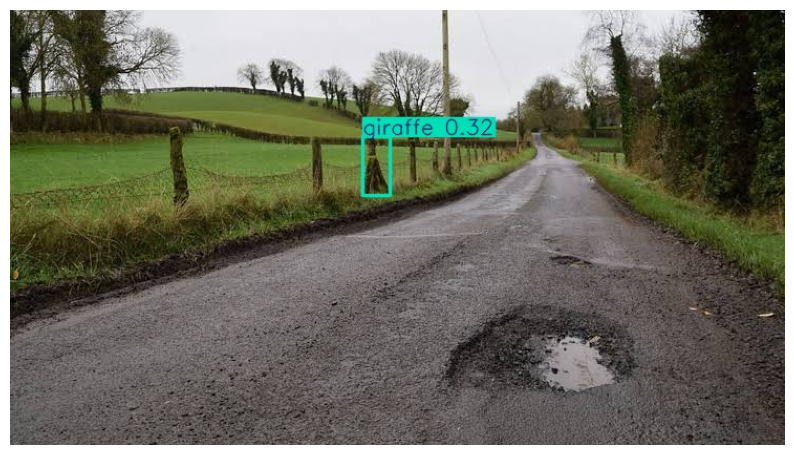

In [7]:
# ============================================
# Display Prediction
# ============================================

from pathlib import Path
from PIL import Image

runs = sorted(Path("runs/detect").glob("predict*"))
latest = runs[-1]

image_path = list(latest.glob("*"))[0]

img = Image.open(image_path)

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")
plt.show()

# Step 6: Understanding YOLO Annotation Format

YOLO stores object annotations using the following format:

```
class_id x_center y_center width height
```

All coordinate values are normalized between 0 and 1.

In [8]:
# ============================================
# Example YOLO Annotation
# ============================================

label = "0 0.53 0.61 0.24 0.18"

parts = label.split()

print(parts)

['0', '0.53', '0.61', '0.24', '0.18']


In [9]:
# ============================================
# Extract Annotation Values
# ============================================

class_id = int(parts[0])

x_center = float(parts[1])
y_center = float(parts[2])
width = float(parts[3])
height = float(parts[4])

print("Class ID :", class_id)
print("X Center :", x_center)
print("Y Center :", y_center)
print("Width    :", width)
print("Height   :", height)

Class ID : 0
X Center : 0.53
Y Center : 0.61
Width    : 0.24
Height   : 0.18


# Progress Summary

At this stage, we have successfully:

- Installed the required libraries.
- Loaded a pretrained YOLOv8 Nano model.
- Uploaded a test image.
- Performed object detection.
- Displayed the prediction results.
- Understood the YOLO annotation format.

The next phase will focus on preparing the Road Damage Dataset (RDD2022) and training a custom YOLOv8 model specifically for road damage detection.

# Observation: Performance of the Pretrained YOLOv8 Model

The pretrained YOLOv8 Nano model was evaluated on a road image containing a visible pothole.

### Results

- The model failed to detect the pothole.
- A tree in the background was incorrectly classified as a **giraffe** with a confidence score of approximately **0.32**.
- No road damage was detected.

### Discussion

This behavior is expected because the pretrained YOLOv8 Nano model is trained on the COCO dataset, which contains 80 everyday object classes such as people, vehicles, and animals. Road damage categories such as potholes and cracks are not included in the COCO dataset.

This experiment demonstrates that a generic object detection model cannot reliably identify road damage without domain-specific training.

### Conclusion

This serves as the baseline experiment for the project. In the next phase, YOLOv8 will be trained on a dedicated road damage dataset (RDD2022) to improve detection performance.

# Step 7: Download the RDD2022 Dataset

The Road Damage Detection 2022 (RDD2022) dataset is used to train a custom YOLOv8 model for detecting road surface damages such as potholes and cracks.

Unlike the pretrained YOLOv8 model trained on the COCO dataset, RDD2022 contains annotated road damage images, making it suitable for this project.

In [11]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [12]:
# ============================================
# Configure Kaggle API
# ============================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API configured successfully!")


✅ Kaggle API configured successfully!


In [13]:
# ============================================
# Test Kaggle Connection
# ============================================

!kaggle datasets list -s "road damage"

ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
alvarobasily/road-damage                                         Road Damage                                          1755838057  2020-08-20 05:33:16.780000           3604         52  0.75             
lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes  Road Damage Dataset: Potholes, Cracks and Manholes    194168092  2026-02-10 15:26:14.110000           3592         34  0.875            
aliabdelmenam/rdd-2022                                           RDD 2022                                            10632799923  2025-02-23 02:30:31.640000          10119         65  0.6875  

In [14]:
!kaggle datasets list -s "RDD2022"

ref                                       title                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  -------------------------  -----------  --------------------------  -------------  ---------  ---------------  
aliabdelmenam/rdd-2022                    RDD 2022                   10632799923  2025-02-23 02:30:31.640000          10119         65  0.6875           
juusos/rdd2022es                          RDD2022ES                   2611933018  2025-05-07 08:54:20.383000            602          6  0.875            
sreekaraditya/rdd2022-yolo-crackscan-v2   RDD2022 YOLO               13259447269  2026-05-16 12:12:18.200000            341          4  0.875            
sujityp/rdd2022                           rdd2022                    11270234471  2024-04-08 13:20:14.960000            721          6  0.0625           
alaagaberh/augmented-rdd2022              Augmented RDD2022          1804359

# Step 8: Verify the Dataset Structure

Before training the model, it is important to verify that the dataset follows the directory structure expected by YOLOv8.

The extracted RDD2022 dataset contains three subsets:

- **train/** – Images used to train the model
- **val/** – Images used to validate model performance during training
- **test/** – Images reserved for final evaluation

Each subset contains:

- **images/** – Road images
- **labels/** – Corresponding YOLO annotation files

This confirms that the dataset is already organized for YOLOv8 training and does not require additional annotation conversion.